# Modeling

This notebook covers the complete machine learning modeling pipeline for the project, including:

* Data Preprocessing
* Feature selection using tree-based models.
* Model experimentation and comparison
* Hyperparameter tunning
* Saving the final model pipeline and configuration. 

----

## Data Preprocessing

To ensure reproducibility, modularity and cleaner experimentation, all preprocessing logic is implemented as reussable functions inside:

    ./src/preprocessing.py

The preprocessing pipeline includes:

* Splitting continuous target value into three classes
* Encoding categorical features
* Feature scaling and normalization
* Train\Test splitting
* Feature engineer utilities

Using centralized preprocessing functions allows the same transformations to be consistentl applied during both training and inference.

----

## Feature Selection

Feature importance is evaluated using tree-based models such as:

* Random Forest
* XGBoost

The most informative features are selected based on importance scores to:

* Reduce noise
* Improve model generalization
* Decrease training time
* Simplify model interpretation

----

## Model Experimentation

Several machine learning models are trained and evaluated, including:

* Logistic Regression
* SVM
* Random Forest
* XGBoost
* CatBoost

Each model is compared using appropriate evaluation metrics such as:

* Accuracy
* F1-Score
* ROC-AUC
* Precision \ Recall

Cross-validation is used to ensure robust evaluation.

----

## Hyperparameter tuning

The best performance models are further optimized using hyperparameter tuning techniques such as:

* GridSearch
* Random Search
* Optuna \ Bayseian Optimization

The tuning process aims to maximize validation performance while preventing overfitting.

----

## Model Saving

The final selected model is exported together with:

* Preprocessing pipeline
* Model parameters
* Feature list
* Training configuration

# Step 1. Data Preprocessing

In this section preprocesssing logic is used from `./src/preprocessing.py`, including:

* Deleteing continuous target classes
* Creating new multiclass-like class `G3_class`
* Creating preprocessor

In [1]:
import pandas as pd
from pathlib import Path
import sys
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

sys.path.append(str(Path("..").resolve()))

DATA_DIR = Path("../dataset/student")

csv_files = list(DATA_DIR.glob("*.csv"))

csv_files

[PosixPath('../dataset/student/student-mat.csv'),
 PosixPath('../dataset/student/student-por.csv')]

In [2]:
df = pd.read_csv(csv_files[1], sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


In [3]:
import src.preprocessing as preprocessing

df = preprocessing.create_class_target_variable(df)
df = preprocessing.delete_continuous_targets(df)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   school      649 non-null    str     
 1   sex         649 non-null    str     
 2   age         649 non-null    int64   
 3   address     649 non-null    str     
 4   famsize     649 non-null    str     
 5   Pstatus     649 non-null    str     
 6   Medu        649 non-null    int64   
 7   Fedu        649 non-null    int64   
 8   Mjob        649 non-null    str     
 9   Fjob        649 non-null    str     
 10  reason      649 non-null    str     
 11  guardian    649 non-null    str     
 12  traveltime  649 non-null    int64   
 13  studytime   649 non-null    int64   
 14  failures    649 non-null    int64   
 15  schoolsup   649 non-null    str     
 16  famsup      649 non-null    str     
 17  paid        649 non-null    str     
 18  activities  649 non-null    str     
 19  nursery     649 non

In [4]:
from sklearn.model_selection import train_test_split

X, y = preprocessing.split_X_y(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, y_train.shape

((519, 30), (519,))

In [5]:
cat_features = X.select_dtypes(include=['string', 'object']).columns
num_features = X.select_dtypes(include=['int']).columns

preprocessor = preprocessing.create_preprocessor(categorical_features=cat_features,
                                                numerical_features=num_features)

# Step 2. Modeling

This section is dedicated to identifying the best baseline model for further optimization and tuning.

The following models will be evaluated:

* `LogisticRegression`
* `RandomForest`
* `SVC`
* `XGBoost`
* `CatBoost`

`XGBoost` and `CatBoost` use separate pipelines due to their model-specific preprocessing requirements and training strategies. 

The remaining scikit-learn models are combined into a single `GridSearch` pipeline.

At the end of this section all models will be compared using the selected evaluation metrics.

Different estimator types require different processing strategies. To simplify experimentation, a custom preprocessing utility was implemented in `./src/preprocessing.py`, allowing flexible configuration of feature transformation.

----

## Evalution metric.

The Student Performance Dataset (Portuguese language version) conatins 649 rows.

After transforming continuous target variable `G3` into a multiclass target (`G3_class`), a strong class imbalance appeared.

The key business question becomes:

1. Should the model prioritize overall predictive performance of majority classes?
2. Or should it prioritize detecting low-performance students despite the class imbalance?

The answer directly affects the choice of *evaluation metrics*.

----

## Important Trade-Off

There is an important trade-off to consider:

* Optimizing for minority-class detection may reduce overall accuracy and increase false positives.
* Optimizing for majority-class performance may cause the model to ignore the minority class entirely.

The primary optimization objective is minority-class recall.

Missing low-performance students is considered more costly than incorrectly flagging average-performing students.

However, since optimizing recall alone may increase false positives, additional evaluation will include:

* macro F1-score
* confustion matrix analysis

In [6]:
preprocessor_num = preprocessing.create_preprocessor(
    categorical_features=cat_features,
    numerical_features=num_features,
    scale_numeric=True,
    encode_categorical="onehot"
)

preprocessor_tree = preprocessing.create_preprocessor(
    categorical_features=cat_features,
    numerical_features=num_features,
    scale_numeric=False,
    encode_categorical="onehot"
)

preprocessor_catboost = preprocessing.create_preprocessor(
    categorical_features=cat_features,
    numerical_features=num_features,
    scale_numeric=False,
    encode_categorical="passthrough"
)

----

## Scikit-learn inbuilt models

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV

baseline_pipeline = Pipeline([
    ("preprocessor", None),
    ("model", None)
])

param_grid = [
    # ========================= Logistic Regresssion =========================
    {
        "model": [LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")],
        "preprocessor": [preprocessor_num],
        "model__C": [0.01, 0.1, 1, 10],
        "model__l1_ratio": [0],
        "model__solver": ["newton-cholesky", "lbfgs"]
    },

    # ========================= SVM =========================
    {
        "model": [SVC(random_state=42, class_weight="balanced")],
        "preprocessor": [preprocessor_num],
        "model__C": [0.01, 0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },

     # ========================= Random Forest =========================
    {
        "model": [RandomForestClassifier(random_state=42, class_weight="balanced")],
        "preprocessor": [preprocessor_tree],
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 10, 20, 50],
        "model__min_samples_split": [2, 5]
    }
]

cv = StratifiedKFold(random_state=42, shuffle=True, n_splits=3)

baseline_grid = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=param_grid,
    scoring="recall_macro",
    n_jobs=-1,
    cv=cv
)

baseline_grid.fit(X_train, y_train)

baseline_model = baseline_grid.best_estimator_
baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [8]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import src.modeling as modeling

y_pred = baseline_model.predict(X_test)

baseline_metrics_df = modeling.calc_model_metrics(y_test=y_test, y_pred=y_pred)

baseline_metrics_df

,metric,value
0,precision macro,0.543561
1,recall macro,0.689010
2,f1 macro,0.549800
3,balanced accuracy,0.689010


In [9]:
type(y_pred)

numpy.ndarray

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.19      0.75      0.30         4
           1       0.79      0.54      0.64        71
           2       0.65      0.78      0.71        55

    accuracy                           0.65       130
   macro avg       0.54      0.69      0.55       130
weighted avg       0.71      0.65      0.66       130



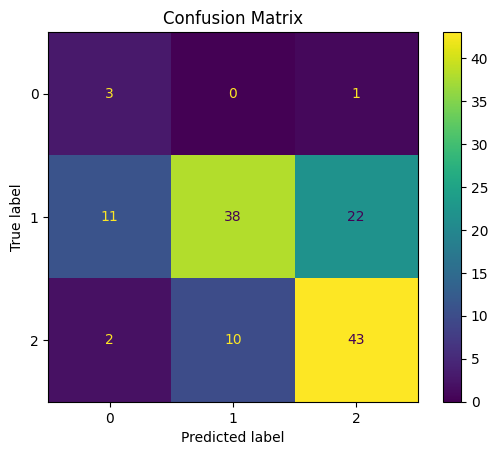

In [11]:
baseline_cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(baseline_cm).plot()

plt.title(f"Confusion Matrix")
plt.show()

### Baseline Models Conclusion

Among the evaluated classical scikit-learn models, `SVC` demonstrated the strongest overall performance under the selected imbalance-oriented evalution strategy.

The model achieved:

* `Precision Macro`: 0.54
* `Balanced Accuracy`: 0.69
* `Recall Macro`: 0.69
* `F1 Macro`: 0.55

The selected optimization strategy focused on `recall_macro`, prioritizing the detection of minority-class students over maximizing overall accuracy.

This decision was motivated by the business objective of identifying potentially low-performing students early enough for possible educational intervention.

The classification report and confusion matrix show that the model successfully learned to detect the minority class entirely.

However this improvemennt introduced a noticeable trade-off:

* minority-class precision remained relatively low (`0.19`)
* the model generated a considerable number of false positive predictions for `Class 0 (C)`

This behavior is expected under severe multiclass imbalance and reflects the model's increased sensitivity toward minority-class detection.

The confusion matrix also indicates that the model still struggles to clearly separate majority classes (`Class 1` and `Class 2`), producing multiple cross-class missclassifications.

Overall the baseline experiments demonstrate that evaluation metric selection strongly influences model behavior in imbalanced multiclass problems.

While `SVC` achieved the best baseline performance among the tested scikit-learn models, further evaluation using gradient boosting methods such as `XGBoost` and `CatBoost` is required to determine whether stronger minority-class handling and better class separation can be achieved. 

## XGBoost

In [12]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

xgboost_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", XGBClassifier(
        random_state=42,
        num_class=3,
        objective="multi:softprob",
        eval_metric="mlogloss"
    ))
])

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 5, 7, 9],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0]
}

cv = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

xgb_grid = GridSearchCV(
    estimator=xgboost_pipeline,
    param_grid=param_grid,
    scoring="recall_macro",
    cv=cv,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train, model__sample_weight=sample_weight)
xgb_model = xgb_grid.best_estimator_

xgb_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [13]:
y_pred = xgb_model.predict(X_test)

xgb_metrics_df = modeling.calc_model_metrics(y_test=y_test, y_pred=y_pred)

xgb_metrics_df

,metric,value
0,precision macro,0.621441
1,recall macro,0.682928
2,f1 macro,0.635343
3,balanced accuracy,0.682928


In [14]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.29      0.50      0.36         4
           1       0.87      0.68      0.76        71
           2       0.71      0.87      0.78        55

    accuracy                           0.75       130
   macro avg       0.62      0.68      0.64       130
weighted avg       0.78      0.75      0.76       130



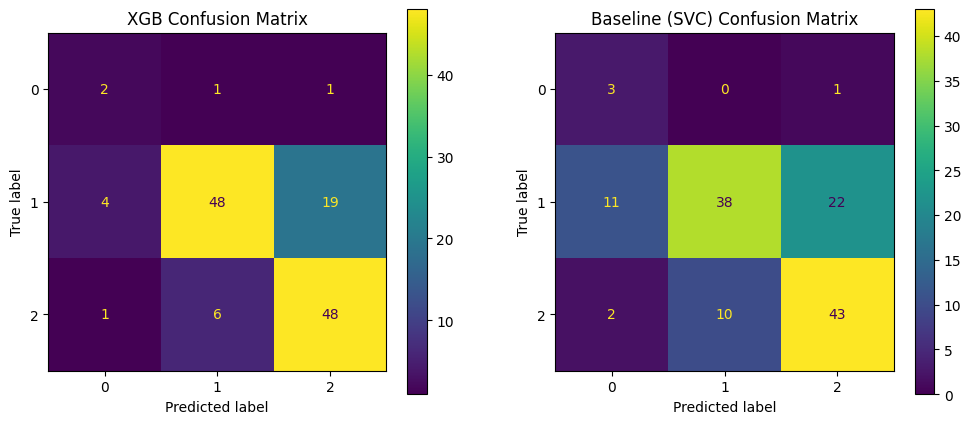

In [15]:
xgb_cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
ConfusionMatrixDisplay(xgb_cm).plot(ax=axes[0])
ConfusionMatrixDisplay(baseline_cm).plot(ax=axes[1])

axes[0].set_title("XGB Confusion Matrix")
axes[1].set_title("Baseline (SVC) Confusion Matrix")
plt.show()

### XGboost Conclusion

In [16]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from xgboost import XGBClassifier

# param_grid = [
#     {
#         "model": [LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")],
#         "model__C": [0.1, 1, 10],
#         "model__solver": ["lbfgs"],

#         "preprocessor": [preprocessing.create_preprocessor(
#             categorical_features=cat_features,
#             numerical_features=num_features,
#             scale_numeric=True,
#             encode_categorical="onehot"
            
#         )]
#     },
#     {
#         "model": [RandomForestClassifier(random_state=42, class_weight="balanced")],
#         "model__n_estimators": [100, 200],
#         "model__max_depth": [None, 10, 20],
#         "model__min_samples_split": [2, 5]
#     },
#     {
#         "model": [SVC(random_state=42, class_weight="balanced")],
#         "model__C": [0.1, 1, 10],
#         "model__kernel": ["linear", "rbf"],
#         "model__gamma": ["scale"]
#     },
#     {
#         "model": [XGBClassifier(random_state=42, eval_metric="mlogloss")],
#         "model__n_estimators": [100, 200],
#         "model__max_depth": [3, 5, 7],
#         "model__learning_rate": [0.01, 0.1],
#         "model__subsample": [0.8, 1.0],
#         "model__colsample_bytree": [0.8, 1.0]
#     }
    
# ]

In [17]:
# models = {
#     "logreg": {
#         "model": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
#         "params": [
#             {
#             "model__C": [0.01, 0.1, 1, 10, 100],
#             "model__l1_ratio": [0, 0.5, 1],
#             "model__solver": ["saga"]
#             },
#             "model__C": [0.11]
#         ]
#     }
# }

In [18]:
# from sklearn.model_selection import GridSearchCV, StratifiedKFold

# cv = StratifiedKFold(random_state=42, n_splits=5, shuffle=True)

# grid = GridSearchCV(
#     estimator=pipeline,
#     scoring="f1_macro",
#     param_grid=param_grid,
#     cv=cv,
#     n_jobs=-1
# )

# grid.fit(X_train, y_train)